In [1]:
import pandas as pd
import numpy as np
import sys,os
sys.path.append("../")
from utils.utils import *
import matplotlib.pyplot as plt
import seaborn as sns
from src.fbsc import plot_signal_drift
from joblib import Parallel,delayed
from tqdm.notebook import tqdm 
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV,LeaveOneOut

In [2]:
D = pd.read_csv("../data/nph_data.csv").drop(columns=['position','mz','rt']).set_index("name").T
M = pd.read_csv("../data/nph_metadata.csv").set_index("sample_name")
M = M.sort_values(by=['batch','injection_order'])
M['injection_order'] = [x for x in range(1,len(M['injection_order'])+1)]
M['batch'].unique()
D = D.replace(128.0,np.nan)

In [3]:
b38 = D.groupby(M['batch']).get_group(38)
b38.loc[b38.index.str.contains("_SP_"),"#2 172.1330@4.8461 MS1+"].isna().any()
b38.iloc[b38.index.str.contains("_SP_"),13]

P_SP_000318   NaN
P_SP_000319   NaN
P_SP_000320   NaN
P_SP_000321   NaN
P_SP_000322   NaN
P_SP_000323   NaN
P_SP_000324   NaN
P_SP_000325   NaN
P_SP_000326   NaN
Name: #14 353.2669@15.7278 MS1+, dtype: float64

# Plot QC Signal Against Injection Order

plotting only QC and Biological Samples


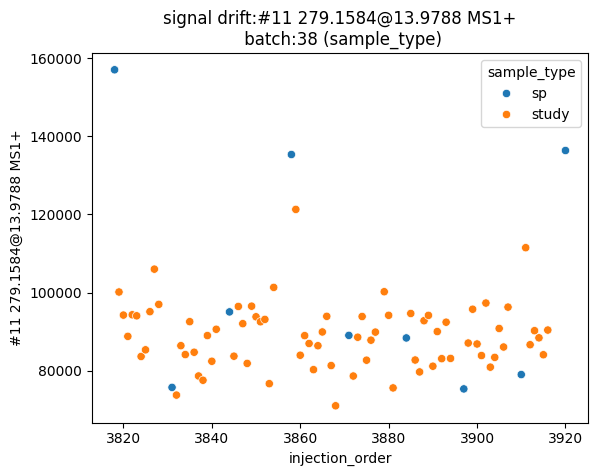

In [4]:
plot_signal_drift(data=D,metadata=M,include_all_samples=False,include_all_batches=False,signal_idx=10)

# Within Batch Effect Correction: QC-SVRC
* RBF function 
* QC signal intensity ~ injection_order (QC signal intensity as a function of injection order)

In [5]:
def svr_function(qc_intensity,bio_intensity,qc_injection_order,bio_injection_order,qc1):
    params = {'kernel':['rbf'],
              'C':[C_param(qc_intensity)],
              'epsilon':[epsilon_param(qc_intensity=qc_intensity,qc1=qc1,pct_precision=15)],
              'gamma':np.logspace(-3,6,base=2)}
    if qc_intensity.isna().sum() >= 5:
        return pd.concat([qc_intensity,bio_intensity],axis=0)
    else: 
        svr = SVR()
        qc_no_outliers = remove_qc_outliers(intensity=qc_intensity)
        qc_inj_no_outliers = qc_injection_order[qc_no_outliers.index]
        X = qc_inj_no_outliers.to_numpy().reshape(-1,1)
        y = qc_no_outliers.to_numpy().ravel()
        cv = GridSearchCV(svr,params,n_jobs=1,scoring='neg_root_mean_squared_error',cv=LeaveOneOut())
        cv.fit(X,y)
        model = cv.best_estimator_
        fitted_values = pd.Series(model.predict(qc_injection_order.to_numpy().reshape(-1,1)),index=qc_intensity.index)
        predicted_values = pd.Series(model.predict(bio_injection_order.to_numpy().reshape(-1,1)),index=bio_intensity.index)
        adjusted_qc = qc_intensity - fitted_values
        adjusted_bio = bio_intensity - predicted_values
    return pd.concat([adjusted_qc,adjusted_bio],axis=0)

def remove_qc_outliers(intensity,method='median'):
    if method == 'IQR':
        Q1 = intensity.quantile(0.25)
        Q3 = intensity.quantile(0.75)
        IQR = Q3 - Q1
        upper_bound = Q1 - 2.5 * IQR
        lower_bound = Q3 + 2.5 * IQR
        no_outliers = intensity[(intensity > upper_bound) & (intensity < lower_bound)]
    if method == 'median':
        lower_threshold = intensity.median() * .20
        no_outliers = intensity[intensity >= lower_threshold]
    return no_outliers
def C_param(qc_intensity,lower=.10,upper=.90):
    C = qc_intensity.quantile(upper) - qc_intensity.quantile(lower)
    return C
def epsilon_param(qc_intensity,qc1,pct_precision=15):
    precision = (pct_precision / 100)
    eps = (precision / 2 )
    eps_scale = (eps * qc_intensity[qc1])
    if bool(np.isnan(eps_scale)):
        eps_scale = qc_intensity.mean() * eps
    return eps_scale

def parallel_svr_correction(data,metadata,n_jobs=-1,qc='SP'):
    group_by_batch = data.groupby(metadata['batch'])
    lst = []
    for idx,batch in group_by_batch:
        QC = batch[batch.index.str.contains(f"{qc}")]
        qc1 = metadata.loc[QC.index, 'injection_order'].idxmin()
        Bio = batch[~batch.index.str.contains(f"{qc}")]
        qc_injection_order = metadata.loc[QC.index,'injection_order']
        bio_injection_order = metadata.loc[Bio.index,'injection_order']
        results = Parallel(n_jobs=n_jobs)(delayed(svr_function)(QC[col],Bio[col],qc_injection_order,bio_injection_order,qc1) for col in tqdm(QC.columns,desc=f'Correcting signals...'))
        results = pd.concat(results,axis=1)
        lst.append(results)
    return pd.concat(lst,axis=0)

def svr_correction(data,metadata,qc='SP'):
    group_by_batch = data.groupby(metadata['batch'])
    lst = []
    for idx,batch in group_by_batch:
        QC = batch[batch.index.str.contains(f"{qc}")]
        qc1 = metadata.loc[QC.index, 'injection_order'].idxmin()
        Bio = batch[~batch.index.str.contains(f"{qc}")]
        qc_injection_order = metadata.loc[QC.index,'injection_order']
        bio_injection_order = metadata.loc[Bio.index,'injection_order']
        for signal in tqdm(data.columns):
            results = svr_function(QC[signal],Bio[signal],qc_injection_order,bio_injection_order,qc1)
            lst.append(results)
    return pd.concat(lst,axis=0)



In [6]:
results = parallel_svr_correction(D,M)

Correcting signals...:   0%|          | 0/12600 [00:00<?, ?it/s]

Correcting signals...:   0%|          | 0/12600 [00:00<?, ?it/s]

KeyboardInterrupt: 

plotting only QC and Biological Samples


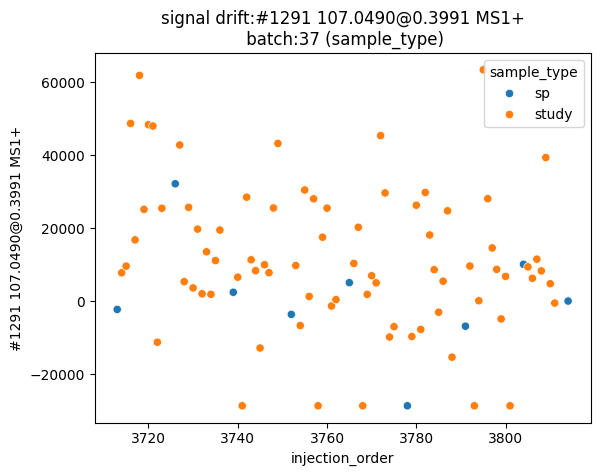

In [ ]:
plot_signal_drift(data=results,metadata=M,include_all_samples=False,include_all_batches=False,random_state=10)

# Between Batch Effect Correction : Ratio-based Method 
- scales the intensity of each metabolic feature in each sample, using a factor defined as the ratio between the median intensity in QCs in corresponsing batch and the median intensity in QCs across batches

- group by batch and take the medians across QC samples 
- group by sample type and take the median across QC samples 

- scale each signal by this ratio 

In [ ]:
def ratio_based_correction(data,metadata,QC='sp'):
    D = data.copy()
    M = metadata.copy()
    QC = D.groupby(M['sample_type']).get_group(QC)
    median_across_qc = QC.median()
    median_qc_by_batch = []
    batches = M['batch'].unique()
    batch_group = QC.groupby(M['batch'])
    for batch in batches:
        median_qc_by_batch.append(batch_group.get_group(batch).median())
    scaling_factor = pd.concat(median_qc_by_batch,axis=1)
    scaling_factor.columns = M['batch'].unique()
    scaling_factor = scaling_factor.div(median_across_qc,axis=0)
    corrected_data = []
    batch_samples = D.groupby(M['batch'])
    for batch in batches:
        corrected_data.append(batch_samples.get_group(batch).mul(scaling_factor[batch],axis=1))
    corrected_data = pd.concat(corrected_data)
    corrected_data = corrected_data.loc[D.index]
    return corrected_data    
df = ratio_based_correction(D,M)